Using device: cuda


100%|██████████| 170M/170M [00:18<00:00, 8.99MB/s]



Training MLP Baseline...
Epoch [1/10] Loss: 1.6677 | Val Acc: 46.93%
Epoch [2/10] Loss: 1.4279 | Val Acc: 50.22%
Epoch [3/10] Loss: 1.3099 | Val Acc: 51.84%
Epoch [4/10] Loss: 1.2116 | Val Acc: 51.91%
Epoch [5/10] Loss: 1.1279 | Val Acc: 52.81%
Epoch [6/10] Loss: 1.0491 | Val Acc: 53.88%
Epoch [7/10] Loss: 0.9681 | Val Acc: 53.90%
Epoch [8/10] Loss: 0.8981 | Val Acc: 54.04%
Epoch [9/10] Loss: 0.8223 | Val Acc: 54.76%
Epoch [10/10] Loss: 0.7486 | Val Acc: 54.24%
Downloading: "https://download.pytorch.org/models/vgg11-8a719046.pth" to /root/.cache/torch/hub/checkpoints/vgg11-8a719046.pth


100%|██████████| 507M/507M [00:02<00:00, 200MB/s]



Training Frozen VGG-11...
Epoch [1/10] Loss: 1.2496 | Val Acc: 66.85%
Epoch [2/10] Loss: 1.0194 | Val Acc: 68.04%
Epoch [3/10] Loss: 0.9678 | Val Acc: 69.53%
Epoch [4/10] Loss: 0.9245 | Val Acc: 70.21%
Epoch [5/10] Loss: 0.8877 | Val Acc: 70.28%
Epoch [6/10] Loss: 0.8543 | Val Acc: 71.45%
Epoch [7/10] Loss: 0.8248 | Val Acc: 70.59%
Epoch [8/10] Loss: 0.8021 | Val Acc: 70.75%
Epoch [9/10] Loss: 0.7705 | Val Acc: 70.66%
Epoch [10/10] Loss: 0.7402 | Val Acc: 70.97%

Training Fine-Tuned VGG-11...
Epoch [1/10] Loss: 1.8425 | Val Acc: 54.92%
Epoch [2/10] Loss: 0.9451 | Val Acc: 75.14%
Epoch [3/10] Loss: 0.6040 | Val Acc: 79.36%
Epoch [4/10] Loss: 0.4238 | Val Acc: 79.73%
Epoch [5/10] Loss: 0.3084 | Val Acc: 81.62%
Epoch [6/10] Loss: 0.2186 | Val Acc: 82.25%
Epoch [7/10] Loss: 0.1727 | Val Acc: 82.47%
Epoch [8/10] Loss: 0.1357 | Val Acc: 82.13%
Epoch [9/10] Loss: 0.1242 | Val Acc: 82.32%
Epoch [10/10] Loss: 0.0983 | Val Acc: 81.99%


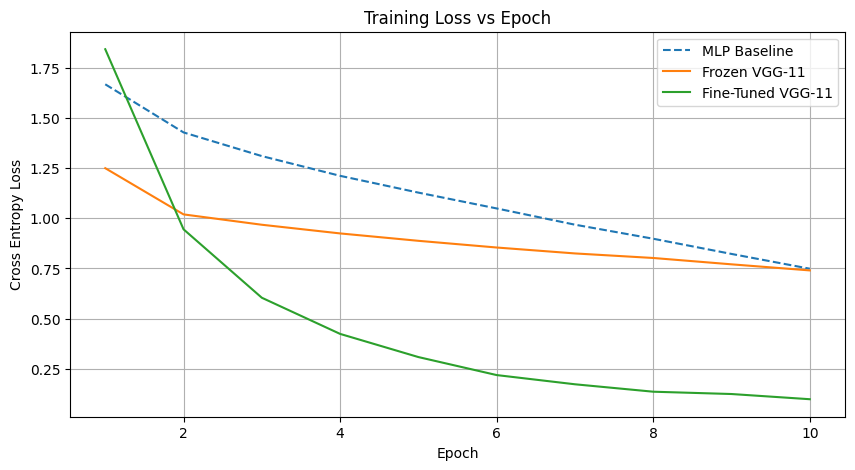

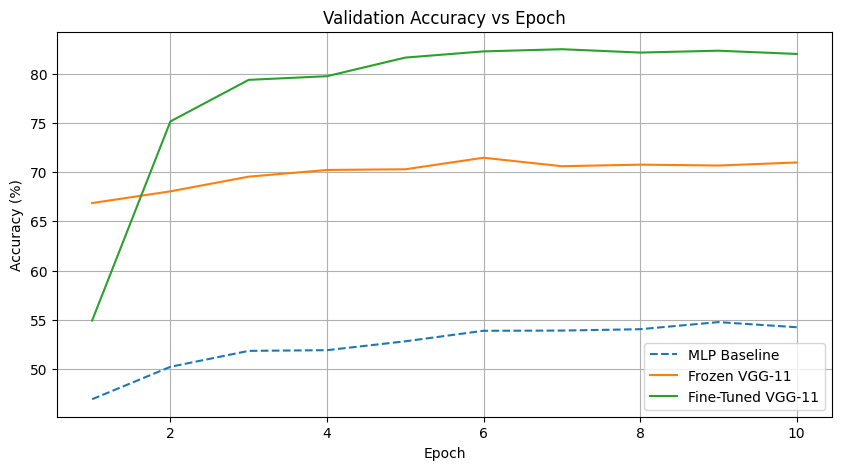

In [2]:
import torch
import torch.nn as nn
import torch.optim as optim
import torchvision
import torchvision.transforms as transforms
import matplotlib.pyplot as plt
import numpy as np


# 1. Setup & Configuration

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

BATCH_SIZE = 512
EPOCHS = 10
LR = 0.001


# 2. Data Pre-processing

# Standard normalization for CIFAR-10
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.4914, 0.4822, 0.4465), (0.2023, 0.1994, 0.2010)),
])

trainset = torchvision.datasets.CIFAR10(root='./data', train=True,
                                        download=True, transform=transform)
trainloader = torch.utils.data.DataLoader(trainset, batch_size=BATCH_SIZE,
                                          shuffle=True, num_workers=2)

testset = torchvision.datasets.CIFAR10(root='./data', train=False,
                                       download=True, transform=transform)
testloader = torch.utils.data.DataLoader(testset, batch_size=BATCH_SIZE,
                                         shuffle=False, num_workers=2)


# 3. Model Architectures

# Model 1: MLP Baseline
class MLP(nn.Module):
    def __init__(self):
        super(MLP, self).__init__()
        self.flatten = nn.Flatten()
        self.layers = nn.Sequential(
            nn.Linear(32 * 32 * 3, 512),
            nn.ReLU(),
            nn.Linear(512, 256),
            nn.ReLU(),
            nn.Linear(256, 10)
        )

    def forward(self, x):
        x = self.flatten(x)
        return self.layers(x)

#  Model 2 & 3: VGG Helpers
from torchvision.models import vgg11, VGG11_Weights

def get_vgg_model(frozen=True):
    # Load pre-trained VGG11
    weights = VGG11_Weights.IMAGENET1K_V1
    model = vgg11(weights=weights)

    # Freeze or Unfreeze features
    for param in model.features.parameters():
        param.requires_grad = not frozen

    # Replace Classifier (CIFAR-10 has 10 classes)
    # VGG original classifier has 4096 hidden units, we adapt it
    model.classifier[6] = nn.Linear(4096, 10)

    return model

# 4. Training Loop
def train_model(model, name):
    print(f"\nTraining {name}...")
    model = model.to(device)
    criterion = nn.CrossEntropyLoss()
    optimizer = optim.Adam(model.parameters(), lr=LR)

    train_losses = []
    val_accuracies = []

    for epoch in range(EPOCHS):
        model.train()
        running_loss = 0.0

        for i, data in enumerate(trainloader, 0):
            inputs, labels = data
            inputs, labels = inputs.to(device), labels.to(device)

            # (a) Zero the parameter gradients
            optimizer.zero_grad()

            # (b) Compute the forward pass
            outputs = model(inputs)

            # (c) Compute the Cross-Entropy loss
            loss = criterion(outputs, labels)

            # (d) Perform backpropagation and update parameters
            loss.backward()
            optimizer.step()

            running_loss += loss.item()

        avg_loss = running_loss / len(trainloader)
        train_losses.append(avg_loss)

        # Validation
        model.eval()
        correct = 0
        total = 0
        with torch.no_grad():
            for data in testloader:
                images, labels = data
                images, labels = images.to(device), labels.to(device)
                outputs = model(images)
                _, predicted = torch.max(outputs.data, 1)
                total += labels.size(0)
                correct += (predicted == labels).sum().item()

        acc = 100 * correct / total
        val_accuracies.append(acc)
        print(f"Epoch [{epoch+1}/{EPOCHS}] Loss: {avg_loss:.4f} | Val Acc: {acc:.2f}%")

    return train_losses, val_accuracies


# 5. Execution & Plotting
# Train MLP
mlp = MLP()
mlp_loss, mlp_acc = train_model(mlp, "MLP Baseline")

# Train Frozen VGG
vgg_frozen = get_vgg_model(frozen=True)
frozen_loss, frozen_acc = train_model(vgg_frozen, "Frozen VGG-11")

# Train Fine-Tuned VGG
vgg_finetuned = get_vgg_model(frozen=False)
ft_loss, ft_acc = train_model(vgg_finetuned, "Fine-Tuned VGG-11")

# Plotting
epochs_range = range(1, EPOCHS + 1)

# Plot Training Loss
plt.figure(figsize=(10, 5))
plt.plot(epochs_range, mlp_loss, label='MLP Baseline', linestyle='--')
plt.plot(epochs_range, frozen_loss, label='Frozen VGG-11')
plt.plot(epochs_range, ft_loss, label='Fine-Tuned VGG-11')
plt.title('Training Loss vs Epoch')
plt.xlabel('Epoch')
plt.ylabel('Cross Entropy Loss')
plt.legend()
plt.grid(True)
plt.savefig('q10_loss.png')
plt.show()

# Plot Validation Accuracy
plt.figure(figsize=(10, 5))
plt.plot(epochs_range, mlp_acc, label='MLP Baseline', linestyle='--')
plt.plot(epochs_range, frozen_acc, label='Frozen VGG-11')
plt.plot(epochs_range, ft_acc, label='Fine-Tuned VGG-11')
plt.title('Validation Accuracy vs Epoch')
plt.xlabel('Epoch')
plt.ylabel('Accuracy (%)')
plt.legend()
plt.grid(True)
plt.savefig('q10_acc.png')
plt.show()